In [25]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()


## HLT 를 먼저 통과 한 이벤트 , hlthps tau 0개 이상인 이벤트만 -> 남은 이벤트 중에서 gen match -> genmatch 가 된 hlthps 의 이벤트를 남겨 놓음  



def get_info (sample):
    file = uproot.open(sample)
    events = file["Events"]
    runs = file["Runs"]
    keys = events.keys()

    tau_pt = events["hltHpsPFTau_pt"].array()
    tau_eta = events["hltHpsPFTau_eta"].array()
    tau_phi = events["hltHpsPFTau_phi"].array()
    

    genvis_tau_pt = events["GenVisTau_pt"].array()
    genvis_tau_eta = events["GenVisTau_eta"].array()
    genvis_tau_phi = events["GenVisTau_phi"].array()
    

    tau_trigger_filter = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array() 
    
    ## final selected variables ( hlthps 있는 이벤트만 남김 )

    idx = ak.argsort(genvis_tau_pt, axis=1, ascending=False)
    genvis_tau_pt = genvis_tau_pt[idx[:, :1]]
    genvis_tau_eta = genvis_tau_eta[idx[:, :1]]
    genvis_tau_phi = genvis_tau_phi[idx[:, :1]]

    final_genvis_tau_pt = genvis_tau_pt
    final_genvis_tau_eta = genvis_tau_eta
    final_genvis_tau_phi = genvis_tau_phi
    
    idx1 = ak.argsort(genvis_tau_pt, axis=1, ascending=False)

    reco_tau_pt = tau_pt[idx1[:, :1]]
    reco_tau_eta = tau_eta[idx1[:, :1]]
    reco_tau_phi = tau_phi[idx1[:, :1]]

    tau_trigger_filtered = tau_trigger_filter

    return final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi , reco_tau_pt, reco_tau_eta, reco_tau_phi,tau_trigger_filtered


def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)


sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150,reco_tau_pt_150, reco_tau_eta_150, reco_tau_phi_150,tau_trigger_filter_150 = get_info(sample)


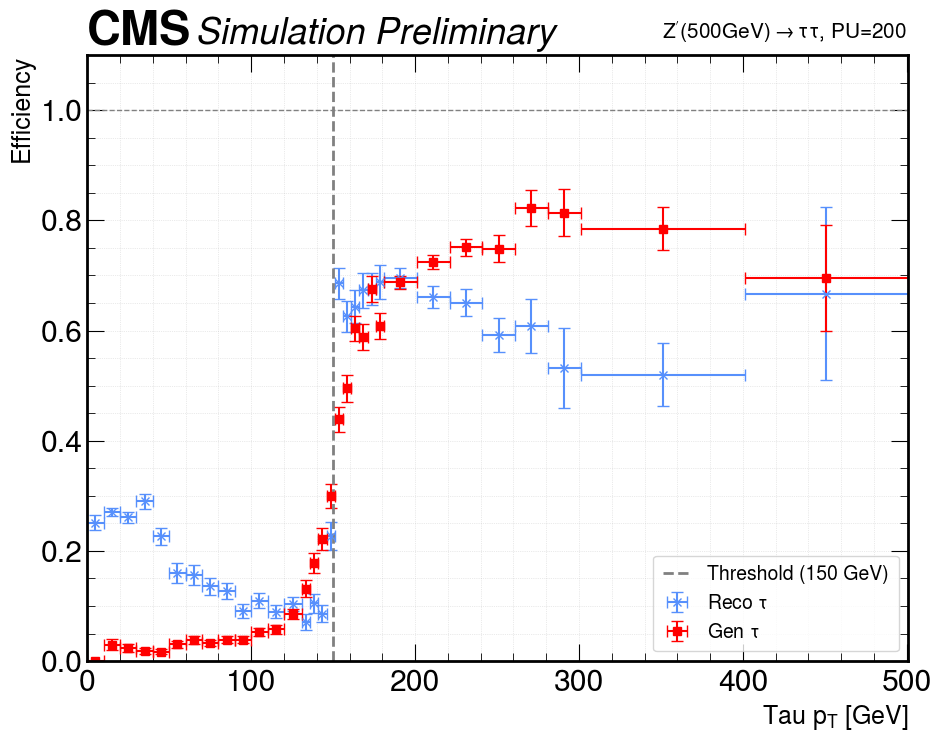

In [26]:

import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt

## 리딩 서브리딩 아무거나 매칭 된 경우 
def returns_num_den (final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi,reco_tau_pt, reco_tau_eta, reco_tau_phi,match_trigger_filter):

    triggered_genvistau_pt = final_genvis_tau_pt[match_trigger_filter]
    triggered_genvistau_eta = final_genvis_tau_eta[match_trigger_filter]
    triggered_genvistau_phi = final_genvis_tau_phi[match_trigger_filter]

    num_pt = triggered_genvistau_pt
    num_eta = triggered_genvistau_eta
    num_phi = triggered_genvistau_phi
    ## denominator ( 모든 genvistau 정보 )
    den_pt = final_genvis_tau_pt
    den_eta = final_genvis_tau_eta
    den_phi = final_genvis_tau_phi

    triggered_reco_tau_pt = reco_tau_pt[match_trigger_filter]
    triggered_reco_tau_eta = reco_tau_eta[match_trigger_filter]
    triggered_reco_tau_phi = reco_tau_phi[match_trigger_filter]

    num_reco_pt = triggered_reco_tau_pt
    num_reco_eta = triggered_reco_tau_eta
    num_reco_phi = triggered_reco_tau_phi

    den_reco_pt = reco_tau_pt
    den_reco_eta = reco_tau_eta
    den_reco_phi = reco_tau_phi

    return num_pt, den_pt, num_eta, den_eta, num_phi, den_phi ,num_reco_pt , den_reco_pt, num_reco_eta, den_reco_eta, num_reco_phi, den_reco_phi

num_pt_gen_150 , den_pt_gen_150, num_eta_gen_150, den_eta_gen_150, num_phi_gen_150, den_phi_gen_150, num_pt_reco_150, den_pt_reco_150, num_eta_reco_150, den_eta_reco_150, num_phi_reco_150, den_phi_reco_150 = returns_num_den (final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150,reco_tau_pt_150, reco_tau_eta_150, reco_tau_phi_150,tau_trigger_filter_150)



bins_0 = np.arange(0, 130, 10)
bins_1 = np.arange(131, 180, 5)
bins_2 = np.arange(181, 300, 20)
bins_3 = np.arange(301, 601, 100)
bins = np.concatenate((bins_0, bins_1, bins_2, bins_3))


## gen
num_pt_gen_150 = ak.flatten(num_pt_gen_150,axis=None)
den_pt_gen_150 = ak.flatten(den_pt_gen_150,axis=None)
num_pt_gen_150 = num_pt_gen_150.to_numpy()
den_pt_gen_150 = den_pt_gen_150.to_numpy()

counts_num_gen_150, edges = np.histogram(num_pt_gen_150, bins=bins)
counts_den_gen_150, _ = np.histogram(den_pt_gen_150, bins=bins)

ratio_gen_150 = np.divide(counts_num_gen_150, counts_den_gen_150, 
                      out=np.zeros_like(counts_num_gen_150, dtype=float), 
                      where=(counts_den_gen_150 != 0))
ratio_err_gen_150 = np.zeros_like(ratio_gen_150)
nonzero_gen_150 = counts_den_gen_150 > 0
ratio_err_gen_150[nonzero_gen_150] = np.sqrt(ratio_gen_150[nonzero_gen_150] * (1.0 - ratio_gen_150[nonzero_gen_150]) / counts_den_gen_150[nonzero_gen_150])


## reco 
num_pt_reco_150 = ak.flatten(num_pt_reco_150,axis=None)
den_pt_reco_150 = ak.flatten(den_pt_reco_150,axis=None)
num_pt_reco_150 = num_pt_reco_150.to_numpy()
den_pt_reco_150 = den_pt_reco_150.to_numpy()

counts_num_reco_150, edges = np.histogram(num_pt_reco_150, bins=bins)
counts_den_reco_150, _ = np.histogram(den_pt_reco_150, bins=bins)

ratio_reco_150 = np.divide(counts_num_reco_150, counts_den_reco_150, 
                      out=np.zeros_like(counts_num_reco_150, dtype=float), 
                      where=(counts_den_reco_150 != 0))
ratio_err_reco_150 = np.zeros_like(ratio_reco_150)
nonzero_reco_150 = counts_den_reco_150 > 0
ratio_err_reco_150[nonzero_reco_150] = np.sqrt(ratio_reco_150[nonzero_reco_150] * (1.0 - ratio_reco_150[nonzero_reco_150]) / counts_den_reco_150[nonzero_reco_150])




# plot with error bars
bin_centers = (edges[:-1] + edges[1:]) / 2.0
half_widths = (edges[1:] - edges[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Reco 데이터
ax.errorbar(bin_centers, ratio_reco_150, xerr=half_widths, yerr=ratio_err_reco_150, 
            fmt='x', color='C0', ecolor='C0', capsize=4,
            label=r'Reco $\tau$') # r을 붙이고 &와 \tau를 확인하세요.

# 2. Gen 데이터
ax.errorbar(bin_centers, ratio_gen_150, xerr=half_widths, yerr=ratio_err_gen_150, 
            fmt='s', color='red', ecolor='red', capsize=4, 
            label=r'Gen $\tau$')

# 축 및 레이블 설정
ax.set_xlabel(r'Tau $p_T$ [GeV]', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges[0], edges[-1])
ax.set_ylim(0, 1.1)

# 트리거 임계값 표시
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
# 레전드 (범례) 설정
ax.legend(loc='lower right', fontsize=14, frameon=True)

# 그리드 및 스타일 마무리
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)

# CMS 정보 표시
hep.cms.text("Simulation Preliminary", loc=0, ax=ax) # loc=0은 상단 왼쪽
ax.text(0.7, 1.06, r"$Z'(500GeV) \to \tau \tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()



In [7]:
print(len(num_pt_gen_150))
print(len(den_pt_gen_150))

6104
6104
